正交矩阵 Q（45度旋转）
Q = 
 [[ 0.707 -0.707]
 [ 0.707  0.707]]

Q^T Q = 
[[ 1. -0.]
 [-0.  1.]]
Q Q^T = 
[[1. 0.]
 [0. 1.]]
Q 的条件数: 1.000 (1 = 最理想)

v = [3 1], ||v|| = 3.162
Qv = [1.414 2.828], ||Qv|| = 3.162
长度是否不变？ True


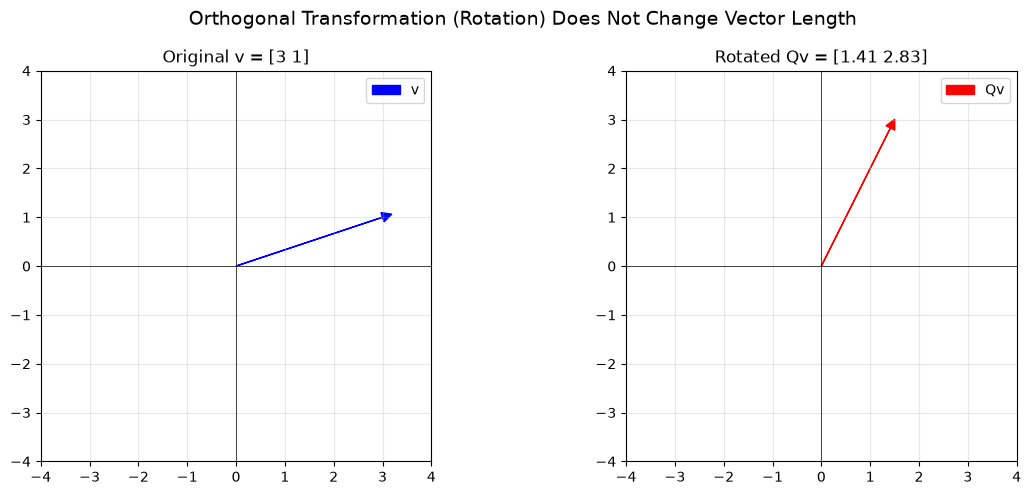


QR 分解：把任意矩阵变成正交矩阵
原始矩阵 A = 
 [[1 2]
 [3 4]
 [5 6]]

Q (正交矩阵) = 
[[-0.169  0.897]
 [-0.507  0.276]
 [-0.845 -0.345]]
R (上三角矩阵) = 
[[-5.916 -7.437]
 [ 0.     0.828]]

Q^T Q = 
[[1. 0.]
 [0. 1.]]
验证: Q @ R = 
[[1. 2.]
 [3. 4.]
 [5. 6.]] (应该等于 A)

用 QR 解最小二乘: x = [1.50129554e-16 5.00000000e-01]
用 lstsq 解: x = [-1.11274361e-16  5.00000000e-01]
差异: 3.43e-16


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 创建一个 2x2 旋转矩阵（正交矩阵） ----
theta = np.pi / 4  # 45度
Q = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)]
])

print("=" * 60)
print("正交矩阵 Q（45度旋转）")
print("=" * 60)
print("Q = \n", Q.round(3))

# ---- 验证正交性 ----
print(f"\nQ^T Q = \n{(Q.T @ Q).round(3)}")  # 应该是 I
print(f"Q Q^T = \n{(Q @ Q.T).round(3)}")  # 应该是 I
print(f"Q 的条件数: {np.linalg.cond(Q):.3f} (1 = 最理想)")

# ---- 长度不变性 ----
v = np.array([3, 1])
Qv = Q @ v
print(f"\nv = {v}, ||v|| = {np.linalg.norm(v):.3f}")
print(f"Qv = {Qv.round(3)}, ||Qv|| = {np.linalg.norm(Qv):.3f}")
print(f"长度是否不变？ {np.isclose(np.linalg.norm(v), np.linalg.norm(Qv))}")

# ---- 正交变换的几何可视化 ----
plt.figure(figsize=(12, 5))

# 原始向量
plt.subplot(1, 2, 1)
plt.arrow(0, 0, v[0], v[1], head_width=0.2, head_length=0.2, fc='blue', ec='blue', label='v')
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(alpha=0.3)
plt.title(f'Original v = {v}')
plt.gca().set_aspect('equal')
plt.legend()

# 变换后的向量
plt.subplot(1, 2, 2)
plt.arrow(0, 0, Qv[0], Qv[1], head_width=0.2, head_length=0.2, fc='red', ec='red', label='Qv')
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(alpha=0.3)
plt.title(f'Rotated Qv = {Qv.round(2)}')
plt.gca().set_aspect('equal')
plt.legend()

# plt.suptitle('正交变换（旋转）不改变向量长度', fontsize=14)
plt.suptitle('Orthogonal Transformation (Rotation) Does Not Change Vector Length', fontsize=14)
plt.tight_layout()
plt.show()

# ---- 用 QR 分解把任意矩阵变成正交矩阵 ----
print("\n" + "=" * 60)
print("QR 分解：把任意矩阵变成正交矩阵")
print("=" * 60)

A = np.array([
    [1, 2],
    [3, 4],
    [5, 6]
])
print("原始矩阵 A = \n", A)

# QR 分解：A = Q @ R，Q 是正交矩阵，R 是上三角矩阵
Q, R = np.linalg.qr(A)
print(f"\nQ (正交矩阵) = \n{Q.round(3)}")
print(f"R (上三角矩阵) = \n{R.round(3)}")

print(f"\nQ^T Q = \n{(Q.T @ Q).round(3)}")  # 应该是 I
print(f"验证: Q @ R = \n{(Q @ R).round(3)} (应该等于 A)")

# ---- QR 分解在最小二乘中的应用 ----
# 用 QR 解最小二乘比正规方程更稳定
# Ax = b → QRx = b → Rx = Q^T b (因为 Q^T Q = I)
b = np.array([1, 2, 3])
x_qr = np.linalg.solve(R, Q.T @ b)
x_lstsq = np.linalg.lstsq(A, b, rcond=None)[0]
print(f"\n用 QR 解最小二乘: x = {x_qr}")
print(f"用 lstsq 解: x = {x_lstsq}")
print(f"差异: {np.linalg.norm(x_qr - x_lstsq):.2e}")